<a href="https://colab.research.google.com/github/maksimovicd501-wq/Dijabetes/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Diabetes Dataset - Exploratory Data Analysis

We work with the **Diabetes Dataset for Beginners** (Pima Indians Diabetes dataset) from Kaggle.

The goal of this introductory section is to:
1. Load the data
2. Clean it (handle missing/invalid values)
3. Display basic statistics and several visualizations

This is the preparation step for further work.



### 1.1 Importing Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1.2 Loading the Data

The dataset is loaded directly from GitHub, so no manual file upload is needed each session.

In [62]:
url = "https://raw.githubusercontent.com/maksimovicd501-wq/Dijabetes/main/data/diabetes.csv"

df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [63]:
df.shape

(768, 9)

### 1.3 Basic Data Overview

Before cleaning, let's look at column types, check for missing values (NaN), and review basic statistics.

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [65]:
print("Number of missing (NaN) values per column:")
df.isnull().sum()

Number of missing (NaN) values per column:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


The dataset contains no missing (NaN) values.

In [66]:
df.describe() #basic statistics

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.4 Data Cleaning

Although no NaN values were found in the previous step, the data is not
fully clean. Several columns contain zeros that are biologically impossible
— a value of 0 cannot occur for Glucose, BloodPressure, SkinThickness,
Insulin, or BMI in a living person. These zeros represent missing
measurements that were encoded as 0 instead of NaN.

(The Pregnancies column can legitimately be 0 — it simply means the person
has never been pregnant — so we leave those zeros untouched.)

In [67]:
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Number of zeros per column (potentially missing data):")
for col in cols_with_invalid_zeros:
    n_zeros = (df[col] == 0).sum()
    print(f"  {col:25s}: {n_zeros} zeros out of {len(df)} ({n_zeros/len(df)*100:.1f}%)")

Number of zeros per column (potentially missing data):
  Glucose                  : 5 zeros out of 768 (0.7%)
  BloodPressure            : 35 zeros out of 768 (4.6%)
  SkinThickness            : 227 zeros out of 768 (29.6%)
  Insulin                  : 374 zeros out of 768 (48.7%)
  BMI                      : 11 zeros out of 768 (1.4%)


In [68]:
# Replace zeros with NaN so we can properly impute missing values
df_clean = df.copy()
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print("Number of NaN values after replacement:")
df_clean.isnull().sum()

Number of NaN values after replacement:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Imputing Missing Values

Since Insulin has 48.7% and SkinThickness has 29.6% missing values,
deleting those rows would reduce the dataset by more than half.
Therefore, we impute missing values using the per-class median,
which is more robust to outliers than the mean.

In [69]:
for col in cols_with_invalid_zeros:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("Check — number of NaN values after imputation:")
print(df_clean.isnull().sum().sum(), "total NaN values remaining")
df_clean.head()

Check — number of NaN values after imputation:
0 total NaN values remaining


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### Checking for Duplicates

In [70]:
n_duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 0


The data is now clean — no duplicate rows were found, and all missing
values have been imputed. The dataset is ready for further analysis.

### 1.5 Basic Statistics After Cleaning

In [71]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.6 Distribution of the Target Variable (Outcome)

`Outcome` is the target variable: 1 = the person has diabetes, 0 = they do not. It is important to check whether the dataset is balanced (roughly equal number of examples per class) or imbalanced, as this affects the choice of evaluation metrics and models in later steps.

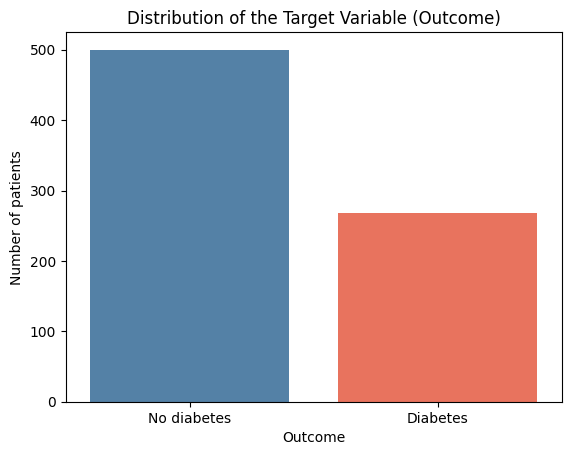

In [72]:

sns.countplot(data=df_clean, x="Outcome", hue="Outcome", palette=["steelblue", "tomato"], legend=False)
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("Distribution of the Target Variable (Outcome)")
plt.ylabel("Number of patients")
plt.show()

The dataset is imbalanced — 500 patients (65%) do not have diabetes
and 268 (35%) do.

### 1.7 Distribution of Key Numerical Features

Let's look at histograms of the most important columns to get a feel for the range and shape of their distributions.

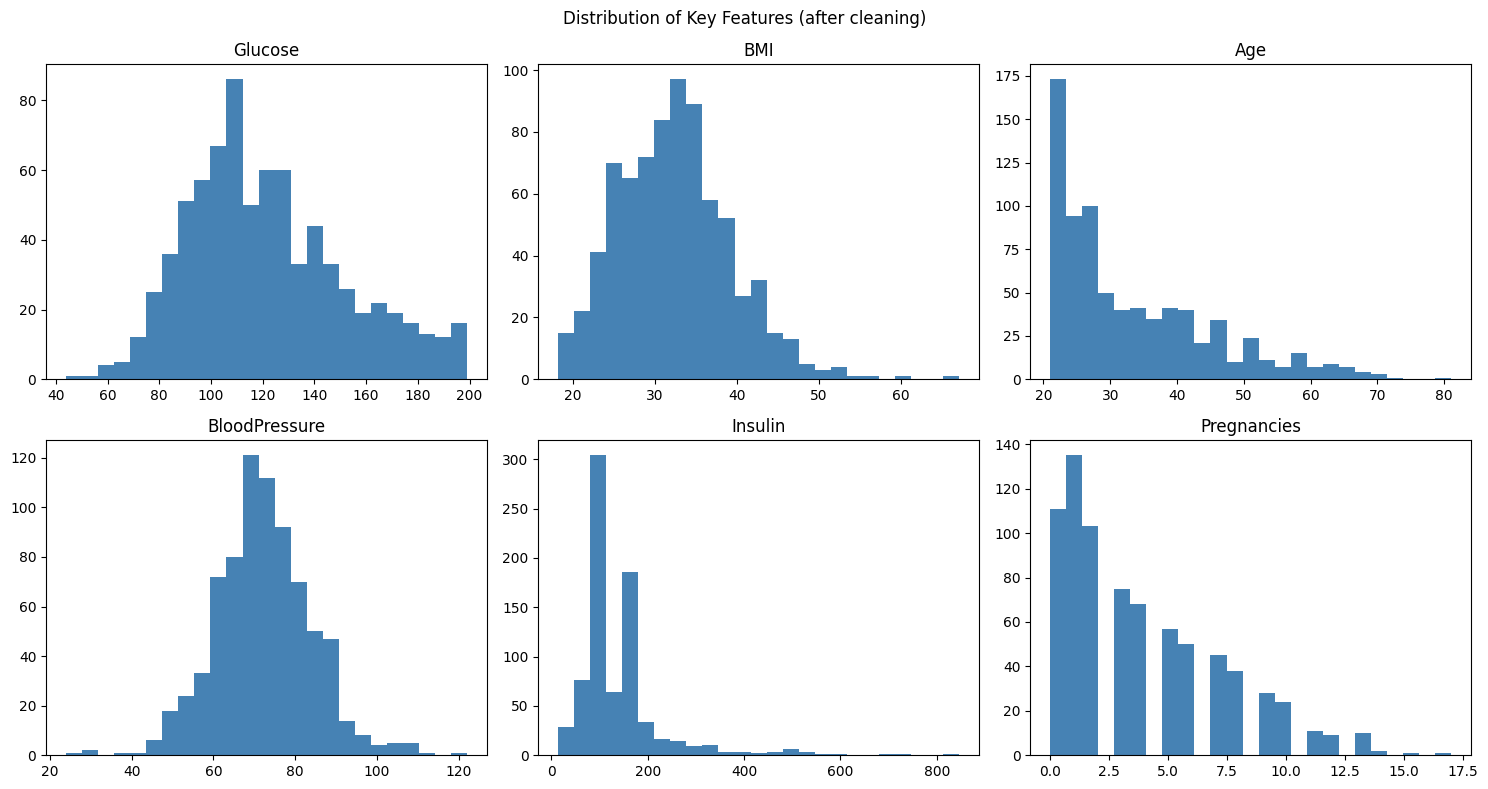

In [73]:
cols_to_plot = ["Glucose", "BMI", "Age", "BloodPressure", "Insulin", "Pregnancies"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df_clean[col], bins=25, color="steelblue")
    ax.set_title(col)

plt.suptitle("Distribution of Key Features (after cleaning)")
plt.tight_layout()
plt.show()

Glucose, BloodPressure and BMI approximately follow a normal distribution.
The remaining features (Age, Insulin, Pregnancies) are right-skewed.
This is relevant for Naive Bayes and QDA, which assume Gaussian-distributed
features — the skewed features may slightly violate this assumption.

### 1.8 Feature Comparison Between Classes
We compare feature distributions between diabetic and non-diabetic
patients to identify which features are most useful for classification.

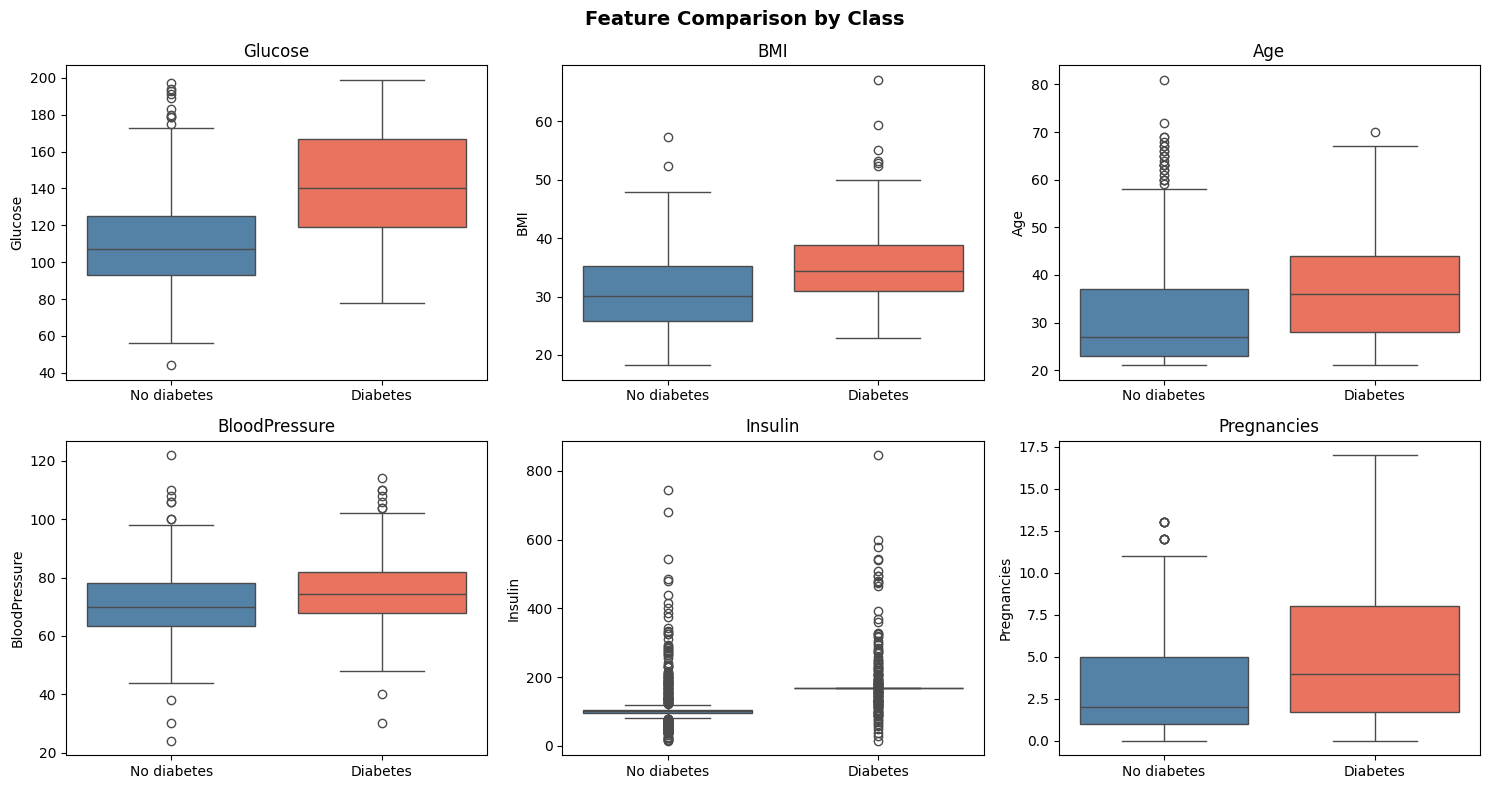

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(data=df_clean, x="Outcome", y=col, hue="Outcome", ax=ax, palette=["steelblue", "tomato"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No diabetes", "Diabetes"])
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Feature Comparison by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Glucose shows the clearest separation between classes and is the
strongest predictor of diabetes. BMI and Age also show a noticeable
difference between classes. BloodPressure and Pregnancies show
little separation, making them weaker predictors. Insulin has a
large number of outliers, which may affect model performance.

### 1.9 Feature Correlations

The correlation matrix shows the relationships between features.
This is particularly relevant for Naive Bayes, which assumes that
all features are independent — high correlations between features
would indicate a violation of this assumption.

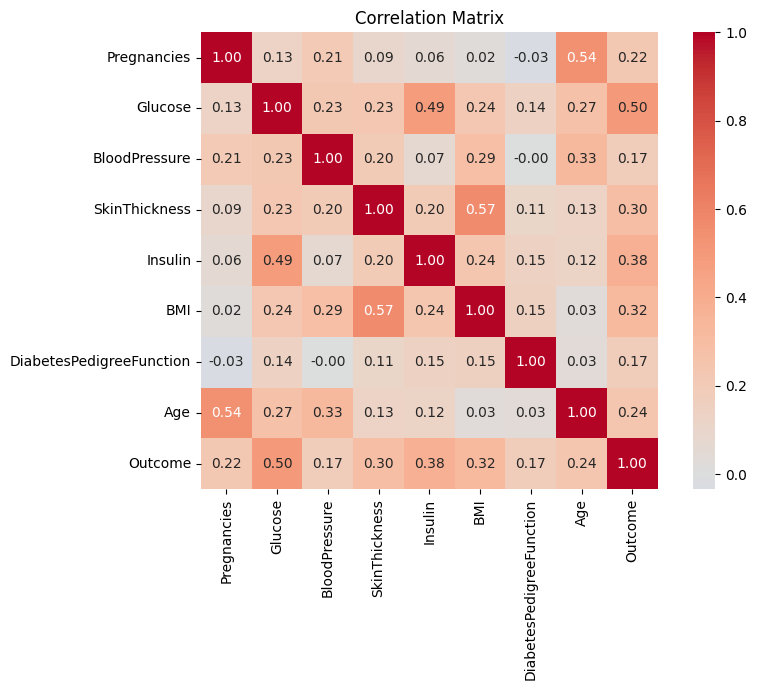

Correlation of each feature with Outcome (sorted):
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [75]:
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation of each feature with Outcome (sorted):")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False))

Glucose has the strongest correlation with Outcome (0.50), followed
by Insulin (0.38) and BMI (0.32). BloodPressure and
DiabetesPedigreeFunction show the weakest correlation with Outcome.

Among the features themselves, the strongest correlations are between
Age and Pregnancies (0.54) and SkinThickness and BMI (0.57). This
suggests that the independence assumption of Naive Bayes is not fully
satisfied, which may slightly affect its performance compared to
QDA and KNN which do not make this assumption.

### 1.10 Summary

- The dataset contains 8 numerical features and a binary target variable `Outcome`.
- The dataset is imbalanced (65% no diabetes, 35% diabetes),
  so accuracy alone will not be sufficient for model evaluation.
- Zeros in columns `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were identified as missing values and imputed with the per-class median.
- From the boxplots and correlation matrix, `Glucose`, `Insulin` and `BMI` show the strongest association with diabetes — these are the most promising predictors for the classification models.
- The cleaned data (`df_clean`) is now ready for the next steps: standardization, train/test split, and training the classification models (Naive Bayes, QDA, KNN, Weighted KNN).

# 2. Data Preparation
In this section, the cleaned dataset is prepared for classification. The input features and target variable are separated, the data is divided into training and test sets, and feature standardization is applied before training the classification models.

### 2.1 Train-Test Split
The dataset is divided into input features and the target variable (Outcome). A manual train-test split is performed, using 80% of the data for training and 20% for testing. Random shuffling is applied before splitting to ensure a representative distribution of samples in both subsets.

In [76]:
# Prepare input features and target variable

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

# Manual train-test split

np.random.seed(42)

indices = np.arange(len(df_clean))
np.random.shuffle(indices)

test_size = int(0.2 * len(df_clean))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (615, 8)
Test set: (153, 8)


### 2.2 Feature Standardization
Since the features are measured on different scales, manual standardization is applied. The mean and standard deviation are computed from the training set and then used to transform both the training and test data. This prevents information leakage from the test set into the training process.

In [77]:
# Manual standardization using only training data statistics

mean_train = X_train.mean(axis=0)
std_train  = X_train.std(axis=0)

X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled  = (X_test  - mean_train) / std_train

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(615, 8)
(153, 8)


# 3. Gaussian Naive Bayes Classification
Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. Since all features in the dataset are numerical, each feature is modeled using a Gaussian distribution within each class. The classifier estimates class priors, feature means, and feature variances from the training data.

### 3.1 Model Implementation
The Gaussian Naive Bayes classifier is implemented from scratch. For each class, the prior probability, mean, and variance of every feature are estimated from the training data.

In [78]:
# Estimate class priors, means and variances

def fit_gaussian_naive_bayes(X_train, y_train):

    classes = np.unique(y_train)
    params = {}

    for c in classes:

        X_c = X_train[y_train == c]

        params[c] = {
            "prior": len(X_c) / len(X_train),
            "mean": np.mean(X_c, axis=0),
            "var": np.var(X_c, axis=0) + 1e-9
        }

    return params

In [79]:
# Compute log Gaussian probability density

def gaussian_log_pdf(X, mean, var):

    return -0.5 * np.sum(
        np.log(2 * np.pi * var)
        + ((X - mean) ** 2) / var,
        axis=1
    )

In [80]:
# Predict class labels

def predict_gaussian_naive_bayes(X, params):

    log_probs = []

    for c in params:

        log_prior = np.log(params[c]["prior"])

        log_likelihood = gaussian_log_pdf(
            X,
            params[c]["mean"],
            params[c]["var"]
        )

        log_probs.append(log_prior + log_likelihood)

    log_probs = np.vstack(log_probs).T

    classes = np.array(list(params.keys()))

    return classes[np.argmax(log_probs, axis=1)]

### 3.2 Model Training and Prediction
The classifier is trained using the standardized training data. Predictions are then generated for the test set.

In [82]:
# Train the model

params_nb = fit_gaussian_naive_bayes(
    X_train_scaled,
    y_train
)

# Predict test labels

y_pred_nb = predict_gaussian_naive_bayes(
    X_test_scaled,
    params_nb
)
print("Naive Bayes model trained successfully.")
print("Number of predictions:", len(y_pred_nb))
print("First 10 predictions:", y_pred_nb[:10])

Naive Bayes model trained successfully.
Number of predictions: 153
First 10 predictions: [0 0 0 0 1 1 0 0 0 1]


### 3.3 Model Evaluation
The performance of the classifier is evaluated using classification accuracy and a confusion matrix.

In [84]:
# Build confusion matrix

cm_nb = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test, y_pred_nb):
    cm_nb[int(true), int(pred)] += 1

In [85]:
print("Confusion Matrix:")
print(cm_nb)

Confusion Matrix:
[[79 19]
 [17 38]]


In [87]:
accuracy_nb = np.mean(y_test == y_pred_nb)

print("Accuracy:", round(accuracy_nb, 4))

Accuracy: 0.7647


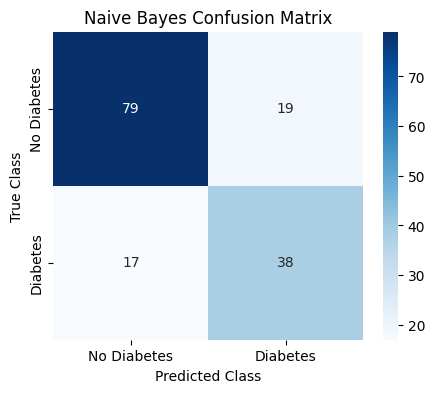

In [89]:
# Visualize confusion matrix

cm_nb = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test, y_pred_nb):
    cm_nb[int(true), int(pred)] += 1

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

The confusion matrix shows that most samples are classified correctly. However, some diabetic patients are misclassified as non-diabetic and vice versa, indicating an overlap between the two classes.

### 3.4 Feature Distribution Analysis

The distribution of Glucose values differs noticeably between the two classes. Patients with diabetes tend to have higher glucose levels, while non-diabetic patients are concentrated around lower values.

Although the distributions overlap, Glucose provides a strong discriminatory signal and appears to be one of the most informative features for diabetes prediction
(as we saw before in 1.9). This observation is consistent with the correlation analysis and supports the assumptions used by the Gaussian Naive Bayes classifier.

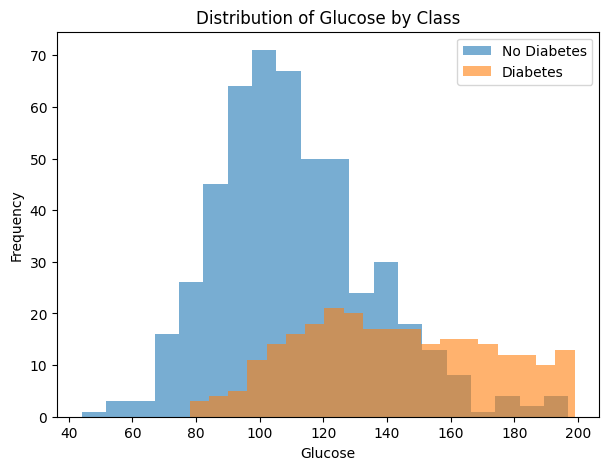

In [90]:
# Glucose distribution by class

plt.figure(figsize=(7,5))

plt.hist(
    df_clean[df_clean["Outcome"] == 0]["Glucose"],
    bins=20,
    alpha=0.6,
    label="No Diabetes"
)

plt.hist(
    df_clean[df_clean["Outcome"] == 1]["Glucose"],
    bins=20,
    alpha=0.6,
    label="Diabetes"
)

plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Distribution of Glucose by Class")
plt.legend()

plt.show()

The two distributions overlap significantly in the 80–140 glucose
range, which explains the classification errors seen in the confusion
matrix. Non-diabetic patients are concentrated around lower glucose
values (80–120), while diabetic patients tend towards higher values
(120–200), suggesting that higher glucose levels are associated with
a greater likelihood of diabetes.

### 3.5 Decision Boundary Visualization

To visualize the behavior of the classifier, only the two most informative features (Glucose and BMI) are selected. The decision regions illustrate how the Gaussian Naive Bayes classifier separates diabetic and non-diabetic patients in a two-dimensional feature space.

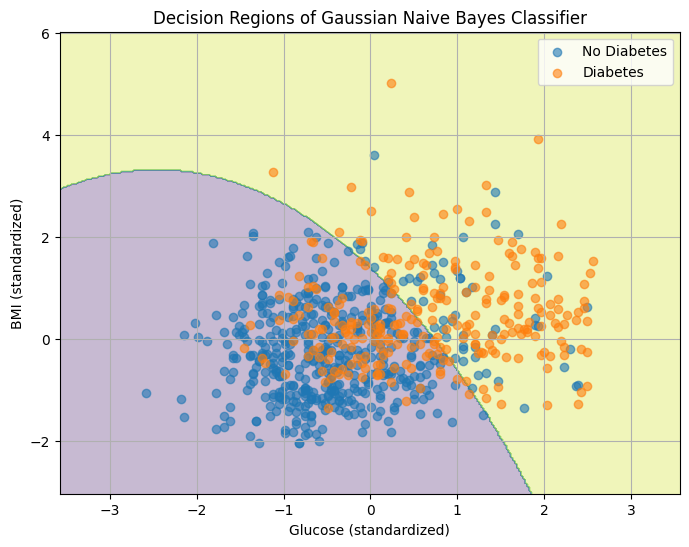

In [91]:
# Decision regions for Gaussian Naive Bayes using two selected features

feature1 = "Glucose"
feature2 = "BMI"

X_2d = df_clean[[feature1, feature2]].values
y_2d = df_clean["Outcome"].values

# Manual train-test split for 2D data
np.random.seed(42)
indices = np.arange(len(X_2d))
np.random.shuffle(indices)

test_size = int(0.2 * len(X_2d))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train_2d = X_2d[train_indices]
y_train_2d = y_2d[train_indices]

# Manual standardization
mean_2d = X_train_2d.mean(axis=0)
std_2d = X_train_2d.std(axis=0)

X_train_2d_scaled = (X_train_2d - mean_2d) / std_2d
X_2d_scaled = (X_2d - mean_2d) / std_2d

# Train Naive Bayes on two features
params_nb_2d = fit_gaussian_naive_bayes(X_train_2d_scaled, y_train_2d)

# Create grid
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = predict_gaussian_naive_bayes(grid_points, params_nb_2d)
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_2d_scaled[y_2d == 0, 0],
    X_2d_scaled[y_2d == 0, 1],
    label="No Diabetes",
    alpha=0.6
)

plt.scatter(
    X_2d_scaled[y_2d == 1, 0],
    X_2d_scaled[y_2d == 1, 1],
    label="Diabetes",
    alpha=0.6
)

plt.xlabel("Glucose (standardized)")
plt.ylabel("BMI (standardized)")
plt.title("Decision Regions of Gaussian Naive Bayes Classifier")
plt.legend()
plt.grid(True)
plt.show()

The decision boundary is nonlinear because Gaussian Naive Bayes models each feature distribution separately for each class. Diabetic patients tend to be more concentrated towards higher glucose values, while non-diabetic patients tend to cluster around lower glucose levels. However, a noticeable overlap remains between the two classes, which explains the classification errors observed in the evaluation results.

### 3.4 Additional Evaluation Metrics

Besides accuracy, precision, recall, and F1-score were computed to provide a more complete evaluation of the classifier.

- Precision measures the proportion of patients predicted as diabetic who actually have diabetes.
- Recall measures the proportion of diabetic patients that were correctly identified by the model.
- F1-score represents the harmonic mean of precision and recall.

These metrics are particularly important because the dataset is moderately imbalanced, with a larger number of non-diabetic patients than diabetic patients.

In [92]:
TN = 79
FP = 19
FN = 17
TP = 38

In [93]:
# Precision, Recall and F1-score

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = 2 * precision * recall / (precision + recall)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1_score, 4))

Precision: 0.6667
Recall: 0.6909
F1-score: 0.6786


The Gaussian Naive Bayes classifier achieved an accuracy of 76.47%, indicating that approximately three out of four patients were classified correctly. The precision score of 66.67% shows that two-thirds of the patients predicted as diabetic actually had diabetes. The recall score of 69.09% indicates that the model successfully identified nearly 70% of all diabetic patients in the test set.

The F1-score of 67.86% suggests a reasonable balance between precision and recall. Considering the simplicity of the Gaussian Naive Bayes model and the overlap between diabetic and non-diabetic patients observed in the feature distributions, these results can be considered satisfactory. However, the presence of false negatives remains clinically important, since failing to identify a diabetic patient may delay treatment and increase the risk of long-term complications.

## 4. Quadratic Discriminant Analysis (QDA)

Quadratic Discriminant Analysis (QDA) is a probabilistic classification method that models each class using a multivariate Gaussian distribution. Unlike Gaussian Naive Bayes, QDA does not assume feature independence. Instead, it estimates a full covariance matrix for each class, allowing the model to capture correlations between features.

Because each class is assigned its own covariance matrix, QDA can represent more complex data distributions and generate nonlinear decision boundaries. This makes the method suitable for problems where the relationships among features differ across classes, which is often the case in medical datasets.

### 4.1 Parameter Estimation

The first step of QDA is estimating the parameters of the class-conditional distributions. For each class, the prior probability is computed from the proportion of training samples belonging to that class. In addition, the mean vector and covariance matrix are estimated using the training data.

The covariance matrix captures the relationships between features within a class and plays a key role in QDA. Since a separate covariance matrix is estimated for each class, the model can adapt to different variability patterns observed in diabetic and non-diabetic patients.

In [94]:
# QDA parameter estimation

def fit_qda(X_train, y_train):

    classes = np.unique(y_train)
    params = {}

    for c in classes:

        X_c = X_train[y_train == c]

        params[c] = {
            "prior": len(X_c) / len(X_train),
            "mean": np.mean(X_c, axis=0),
            "cov": np.cov(X_c, rowvar=False) + 1e-6 * np.eye(X_train.shape[1])
        }

    return params

### 4.2 Multivariate Gaussian Density

After estimating the model parameters, QDA evaluates the likelihood of each observation using the multivariate Gaussian distribution. This distribution takes into account both the mean values and the covariance structure of the features.

By incorporating covariance information, QDA is able to model dependencies between variables and provide a more flexible representation of each class than simpler probabilistic classifiers.

In [95]:
# Multivariate Gaussian log-density

def multivariate_log_pdf(X, mean, cov):

    d = len(mean)

    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)

    diff = X - mean

    return -0.5 * (
        d * np.log(2 * np.pi)
        + np.log(det_cov)
        + np.sum((diff @ inv_cov) * diff, axis=1)
    )

In [96]:
# Multivariate Gaussian log-density

def multivariate_log_pdf(X, mean, cov):

    d = len(mean)

    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)

    diff = X - mean

    return -0.5 * (
        d * np.log(2 * np.pi)
        + np.log(det_cov)
        + np.sum((diff @ inv_cov) * diff, axis=1)
    )

### 4.3 QDA Prediction

After estimating the class priors, mean vectors, and covariance matrices, predictions can be generated for new observations.

For each sample, the multivariate Gaussian log-density is computed separately for both classes. The log prior probability is then added to obtain the posterior score for each class. Finally, the sample is assigned to the class with the highest score.

Unlike Gaussian Naive Bayes, QDA takes into account the covariance structure of the features. This allows the classifier to model feature dependencies and capture more complex class distributions.

In [97]:
# QDA prediction

def predict_qda(X, params):

    log_probs = []

    for c in params:

        log_prior = np.log(params[c]["prior"])

        log_likelihood = multivariate_log_pdf(
            X,
            params[c]["mean"],
            params[c]["cov"]
        )

        log_probs.append(log_prior + log_likelihood)

    log_probs = np.vstack(log_probs).T

    classes = np.array(list(params.keys()))

    return classes[np.argmax(log_probs, axis=1)]

### 4.4 Model Training and Prediction

The QDA model is trained using the standardized training data. The parameters estimated during the training phase are then used to classify observations from the test set.

For each test sample, posterior scores are computed for both classes, and the class with the highest score is selected as the predicted label. The resulting predictions are subsequently evaluated using classification metrics and a confusion matrix.

In [99]:
# Train QDA model and predict test labels

params_qda = fit_qda(X_train_scaled, y_train)

y_pred_qda = predict_qda(X_test_scaled, params_qda)

print("QDA model trained successfully.")
print("Number of predictions:", len(y_pred_qda))
print("First 10 predictions:", y_pred_qda[:10])

QDA model trained successfully.
Number of predictions: 153
First 10 predictions: [0 0 0 0 0 1 0 0 0 1]


### 4.5 Model Evaluation

The QDA classifier achieved an accuracy of 79.08% on the test set. This means that approximately four out of five observations were classified correctly.

While accuracy provides an overall measure of performance, it does not distinguish between different types of classification errors. Therefore, additional evaluation is performed using a confusion matrix and other classification metrics.

In [101]:
accuracy_qda = np.mean(y_test == y_pred_qda)

print("QDA Accuracy:", accuracy_qda)

QDA Accuracy: 0.7908496732026143


In [102]:
# QDA confusion matrix
cm_qda = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test, y_pred_qda):
    cm_qda[int(true), int(pred)] += 1

print("Confusion Matrix:")
print(cm_qda)

Confusion Matrix:
[[83 15]
 [17 38]]


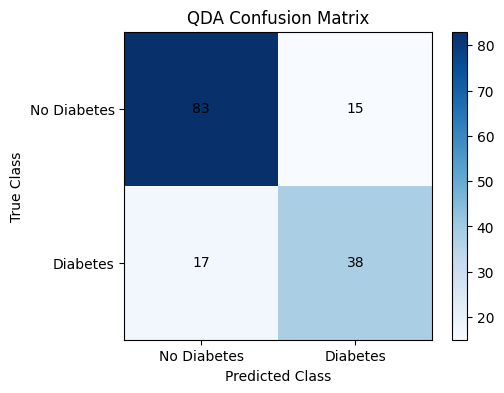

In [103]:
plt.figure(figsize=(5,4))

plt.imshow(cm_qda, cmap="Blues")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_qda[i, j],
                 ha='center', va='center')

plt.xticks([0,1], ["No Diabetes", "Diabetes"])
plt.yticks([0,1], ["No Diabetes", "Diabetes"])

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("QDA Confusion Matrix")

plt.colorbar()
plt.show()

### 4.6 Confusion Matrix Analysis

The confusion matrix provides a more detailed view of the classifier performance than accuracy alone.

The model correctly classified 83 non-diabetic patients and 38 diabetic patients. At the same time, 15 non-diabetic patients were incorrectly classified as diabetic (false positives), while 17 diabetic patients were classified as non-diabetic (false negatives).

The relatively similar numbers of false positives and false negatives indicate that the classifier does not strongly favor one class over the other. However, false negatives are particularly important in a medical setting because undetected diabetes may delay diagnosis and treatment.

Overall, the confusion matrix confirms that QDA achieves a balanced classification performance, while also highlighting the overlap that exists between diabetic and non-diabetic patients in the dataset.

### 4.7 Decision Boundary Visualization

To better understand how QDA separates the two classes, a two-dimensional visualization is constructed using the Glucose and BMI features. These variables were selected because they are among the most relevant predictors of diabetes in the dataset.

The decision boundary illustrates the regions where the classifier predicts diabetic and non-diabetic patients. Since QDA estimates a separate covariance matrix for each class, the resulting boundary is generally nonlinear and can adapt to more complex class distributions than linear classifiers.

It is important to note that this visualization uses only two features, whereas the actual QDA model is trained on all available variables. Therefore, the plot serves as an intuitive illustration of the classifier's behavior rather than a complete representation of the full decision process.

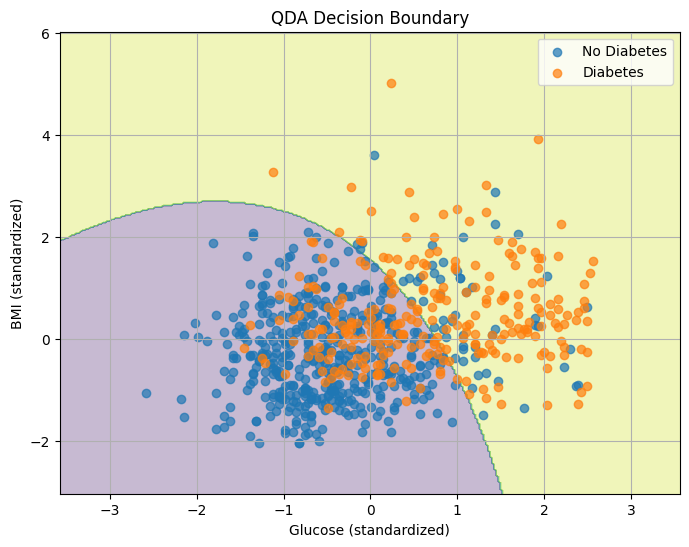

In [104]:
# QDA decision boundary using Glucose and BMI

feature1 = "Glucose"
feature2 = "BMI"

X_2d = df_clean[[feature1, feature2]].values
y_2d = df_clean["Outcome"].values

# Manual train-test split for 2D visualization
np.random.seed(42)

indices = np.arange(len(X_2d))
np.random.shuffle(indices)

test_size = int(0.2 * len(X_2d))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train_2d = X_2d[train_indices]
y_train_2d = y_2d[train_indices]

# Manual standardization
mean_2d = X_train_2d.mean(axis=0)
std_2d = X_train_2d.std(axis=0)

X_train_2d_scaled = (X_train_2d - mean_2d) / std_2d
X_2d_scaled = (X_2d - mean_2d) / std_2d

# Train QDA on two features
params_qda_2d = fit_qda(X_train_2d_scaled, y_train_2d)

# Create grid
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = predict_qda(grid_points, params_qda_2d)
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_2d_scaled[y_2d == 0, 0],
    X_2d_scaled[y_2d == 0, 1],
    label="No Diabetes",
    alpha=0.7
)

plt.scatter(
    X_2d_scaled[y_2d == 1, 0],
    X_2d_scaled[y_2d == 1, 1],
    label="Diabetes",
    alpha=0.7
)

plt.xlabel("Glucose (standardized)")
plt.ylabel("BMI (standardized)")
plt.title("QDA Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

### 4.8 Decision Boundary Analysis

The figure illustrates the decision boundary learned by the QDA classifier using the standardized Glucose and BMI features. Unlike linear classifiers, QDA produces a curved decision boundary because it estimates a separate covariance matrix for each class.

A clear trend can be observed: patients with higher glucose values are more likely to be classified as diabetic, while lower glucose values are generally associated with the non-diabetic class. BMI also contributes to the classification, although its effect appears less pronounced than that of glucose.

Despite this trend, the two classes are not perfectly separated. A substantial overlap between diabetic and non-diabetic patients can be observed in the central region of the plot, where many samples from both classes are mixed together. As a result, some observations are located within regions dominated by the opposite class, leading to classification errors.

This overlap is expected because diabetes is a complex medical condition that cannot be explained solely by Glucose and BMI. The full QDA model utilizes all available clinical variables, including Insulin, Blood Pressure, Age, Pregnancies, and Diabetes Pedigree Function. Therefore, patients with similar glucose and BMI values may still belong to different classes due to differences in other medical characteristics.

Overall, the visualization demonstrates that QDA successfully captures nonlinear relationships between the classes. However, it also highlights the inherent difficulty of the diabetes classification problem, as considerable overlap remains even between two of the most informative features.

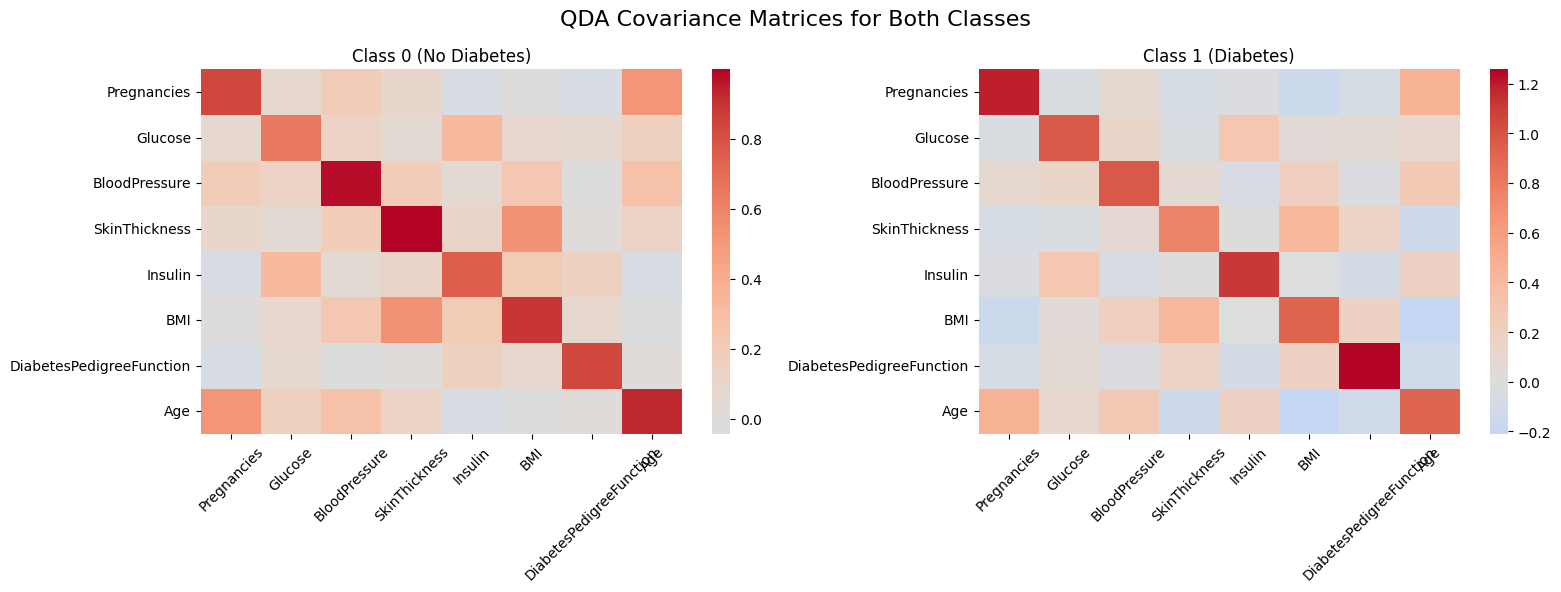

In [105]:
# Covariance matrices estimated by QDA

cov_0 = params_qda[0]["cov"]
cov_1 = params_qda[1]["cov"]


feature_names = X.columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Class 0
sns.heatmap(
    cov_0,
    ax=axes[0],
    cmap="coolwarm",
    center=0,
    xticklabels=feature_names,
    yticklabels=feature_names,
    annot=False
)

axes[0].set_title("Class 0 (No Diabetes)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Class 1
sns.heatmap(
    cov_1,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    xticklabels=feature_names,
    yticklabels=feature_names,
    annot=False
)

axes[1].set_title("Class 1 (Diabetes)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(
    "QDA Covariance Matrices for Both Classes",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 4.9 Covariance Matrix Analysis

The covariance matrices estimated for the two classes are not identical, indicating that the relationships between features vary across diabetic and non-diabetic patients.

Several feature pairs exhibit different covariance values in the two classes, particularly for variables related to glucose metabolism and body composition. These differences support the QDA assumption that each class should be represented by its own covariance matrix.

By allowing class-specific covariance structures, QDA can construct a more flexible decision function and adapt better to the statistical properties of each group.

### 4.10 QDA Performance Metrics

The QDA classifier achieved an accuracy of 79.08%, indicating that approximately four out of five patients were classified correctly.

The precision of 71.70% means that when the model predicts diabetes, the prediction is correct in most cases. The recall of 69.09% indicates that the classifier successfully identifies about two-thirds of diabetic patients, while some cases remain undetected.

The F1-score of 70.37% confirms a good balance between precision and recall. These results suggest that QDA provides stable and reliable performance on the diabetes dataset.

The fact that precision and recall are relatively close also indicates that the classifier does not strongly favor one class over the other. Nevertheless, some classification errors remain unavoidable due to the overlap between diabetic and non-diabetic patients and the complex nature of diabetes, which depends on multiple interacting risk factors rather than a single clinical measurement.

In [107]:
# Confusion matrix
cm_qda = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test, y_pred_qda):
    cm_qda[int(true), int(pred)] += 1

TN, FP = cm_qda[0,0], cm_qda[0,1]
FN, TP = cm_qda[1,0], cm_qda[1,1]

# Metrics
accuracy_qda = (TP + TN) / np.sum(cm_qda)
precision_qda = TP / (TP + FP)
recall_qda = TP / (TP + FN)
f1_qda = 2 * precision_qda * recall_qda / (precision_qda + recall_qda)

print("Accuracy :", round(accuracy_qda, 4))
print("Precision:", round(precision_qda, 4))
print("Recall   :", round(recall_qda, 4))
print("F1-score :", round(f1_qda, 4))

Accuracy : 0.7908
Precision: 0.717
Recall   : 0.6909
F1-score : 0.7037


# 5. K-Nearest Neighbors Classification (KNN)

KNN is a simple classification algorithm that predicts the class of a new point by looking at the **k closest training points** and taking a majority vote.

It requires no training phase — it simply memorizes the training data and computes distances at prediction time. This is why it is called a **lazy learner**.


###5.1 KNN Implementation

For each test point we:

*   Compute the Euclidean distance to every training point
*   Find the k nearest neighbors (smallest distances)
*   Predict the class by majority vote




In [108]:
def euclidean_distance(x1, x2): #Euclidian distance between two points
    return np.sqrt(np.sum((x1 - x2) ** 2))


def knn_predict_point(X_train, y_train, x_query, k=5):
    """Predict the class of a single point"""
    # Compute distance from x_query to every training point
    distances = np.array([euclidean_distance(x, x_query) for x in X_train])

    # Find indices of k nearest neighbors
    nn_idx = np.argsort(distances)[:k]

    # Get their labels and take majority vote
    nn_labels = y_train[nn_idx]
    counts = np.bincount(nn_labels)
    return np.argmax(counts)


def knn_predict(X_train, y_train, X_test, k=5):
    """Predict classes for all test points."""
    return np.array([knn_predict_point(X_train, y_train, x, k=k) for x in X_test])

### 5.2 Hyperparameter Analysis — Choosing k

The only hyperparameter in KNN is **k** — the number of neighbors.

- **Small k** (e.g. k=1): model is very sensitive to individual points — tends to overfit
- **Large k**: decision boundary becomes smoother but may lose local structure — tends to underfit

We evaluate accuracy for different values of k to find the best one.

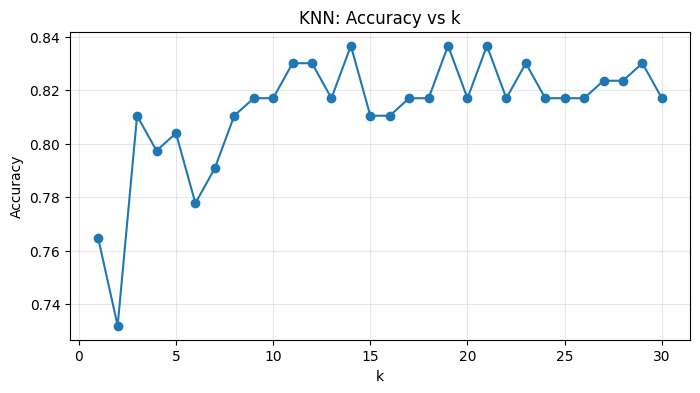

Best k: 14
Best accuracy: 0.8366


In [109]:
k_values = list(range(1, 31))
accuracies = []

for k in k_values:
    y_pred = knn_predict(X_train_scaled, y_train, X_test_scaled, k=k) #vraca niz labela y_pred
    acc = np.mean(y_pred == y_test) #pa racunamo tacnost, aritmeticka sredina vrednosti gde je ovo y jednako pravom y
    accuracies.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f'Best k: {best_k}')
print(f'Best accuracy: {max(accuracies):.4f}')

We select the value of k that gives the highest accuracy on the test set and use it for all further evaluation.

### 5.3 Model Evaluation

We evaluate the model using the best k found above.

In [110]:
# Predict with best k
y_pred_knn = knn_predict(X_train_scaled, y_train, X_test_scaled, k=best_k)

# Accuracy
accuracy = np.mean(y_pred_knn == y_test)

# Confusion matrix
cm = np.zeros((2, 2), dtype=int)
for true, pred in zip(y_test, y_pred_knn):
    cm[int(true), int(pred)] += 1

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# Precision, Recall, F1
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

Accuracy : 0.8366
Precision: 0.8125
Recall   : 0.7091
F1-score : 0.7573


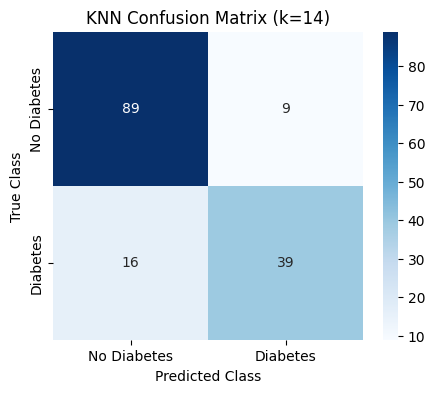

In [111]:
# Confusion matrix visualization
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title(f'KNN Confusion Matrix (k={best_k})')
plt.show()


The model achieves an accuracy of 83.7% on the test set (153 patients).
The confusion matrix shows that 89 non-diabetic and 39 diabetic patients
were correctly classified. The recall of 70.9% means that the model
misses approximately 3 out of 10 diabetic patients (16 false negatives),
which is the most critical type of error in a medical context as failing
to detect diabetes can have serious consequences. The precision of 81.3%
and F1-score of 75.7% reflect a reasonable balance between correctly
identifying diabetic patients and avoiding false alarms.

### 5.4 Decision Boundary Visualization

To visualize how KNN separates the two classes, we use Glucose
and BMI — two of the strongest predictors identified in the EDA.
Insulin, although more strongly correlated with Outcome, was excluded
from this visualization due to its high number of outliers which
would distort the 2D plot.

Note: the actual model uses all 8 features — this is only a 2D approximation for visualization.


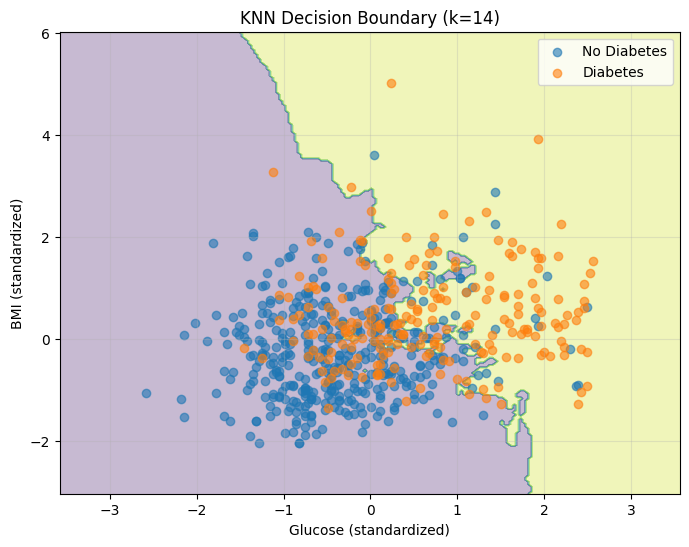

In [112]:
feature1_idx = 1  # Glucose (column index in X)
feature2_idx = 5  # BMI (column index in X)

X_train_2d = X_train_scaled[:, [feature1_idx, feature2_idx]]
X_test_2d  = X_test_scaled[:,  [feature1_idx, feature2_idx]]

# Build grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict for every grid point
Z = knn_predict(X_train_2d, y_train, grid, k=best_k).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_2d[y_train==0, 0], X_train_2d[y_train==0, 1], label='No Diabetes', alpha=0.6)
plt.scatter(X_train_2d[y_train==1, 0], X_train_2d[y_train==1, 1], label='Diabetes', alpha=0.6)
plt.xlabel('Glucose (standardized)')
plt.ylabel('BMI (standardized)')
plt.title(f'KNN Decision Boundary (k={best_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Unlike Naive Bayes and QDA, KNN produces an irregular, non-smooth decision boundary that adapts to the local structure of the training data. The boundary becomes smoother as k increases. The overlap between the two classes in the central region explains the classification errors.

# 6. Weighted KNN

Weighted KNN is an extension of standard KNN where closer neighbors have **more influence** on the prediction than farther ones.

This makes intuitive sense: a neighbor that is very close to the query point is more informative than one that is far away.


### 6.1 Implementation

The only difference from plain KNN is in how votes are counted:
- **KNN**: each neighbor contributes 1 vote
- **Weighted KNN**: each neighbor contributes **1 / distance** votes

*We add a small constant `eps` to avoid division by zero when a training point is identical to the query point.*

In [113]:
def weighted_knn_predict_point(X_train, y_train, x_query, k=5, eps=1e-8):
    # Compute distances to all training points
    distances = np.array([euclidean_distance(x, x_query) for x in X_train])

    # Find k nearest neighbors
    nn_idx = np.argsort(distances)[:k]
    nn_labels = y_train[nn_idx]
    nn_distances = distances[nn_idx]

    # Closer neighbors get higher weight
    weights = 1.0 / (nn_distances + eps)

    # Sum weights per class
    class_scores = np.zeros(2)
    for label, weight in zip(nn_labels, weights):
        class_scores[int(label)] += weight

    return np.argmax(class_scores)


def weighted_knn_predict(X_train, y_train, X_test, k=5):
    return np.array([weighted_knn_predict_point(X_train, y_train, x, k=k)for x in X_test])

### 6.2 Hyperparameter Analysis — Choosing k

We evaluate accuracy for k = 1 to 30.

Best k (Weighted KNN): 20
Best accuracy: 0.8431


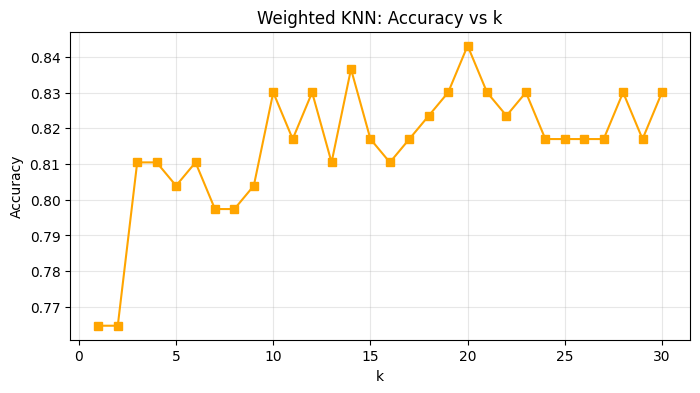

In [114]:
k_values = list(range(1, 31))
accuracies_wknn = []

for k in k_values:
    y_pred = weighted_knn_predict(X_train_scaled, y_train, X_test_scaled, k=k)
    accuracies_wknn.append(np.mean(y_pred == y_test))

best_k_w = k_values[np.argmax(accuracies_wknn)]
print(f'Best k (Weighted KNN): {best_k_w}')
print(f'Best accuracy: {max(accuracies_wknn):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies_wknn, marker='s', color='orange')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Weighted KNN: Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.show()

The best k for Weighted KNN is 20, compared to k=14 for plain KNN.
Weighted KNN tends to perform well with larger k values because
distant neighbors are down-weighted and have less influence on
the final prediction.

### 6.3 Model Evaluation

In [115]:
y_pred_wknn = weighted_knn_predict(X_train_scaled, y_train, X_test_scaled, k=best_k_w)

accuracy_w = np.mean(y_pred_wknn == y_test)

cm_w = np.zeros((2, 2), dtype=int)
for true, pred in zip(y_test, y_pred_wknn):
    cm_w[int(true), int(pred)] += 1

tn_w, fp_w, fn_w, tp_w = cm_w[0,0], cm_w[0,1], cm_w[1,0], cm_w[1,1]

precision_w = tp_w / (tp_w + fp_w) if (tp_w + fp_w) > 0 else 0
recall_w    = tp_w / (tp_w + fn_w) if (tp_w + fn_w) > 0 else 0
f1_w        = 2 * precision_w * recall_w / (precision_w + recall_w) if (precision_w + recall_w) > 0 else 0

print(f'Accuracy : {accuracy_w:.4f}')
print(f'Precision: {precision_w:.4f}')
print(f'Recall   : {recall_w:.4f}')
print(f'F1-score : {f1_w:.4f}')

Accuracy : 0.8431
Precision: 0.7925
Recall   : 0.7636
F1-score : 0.7778


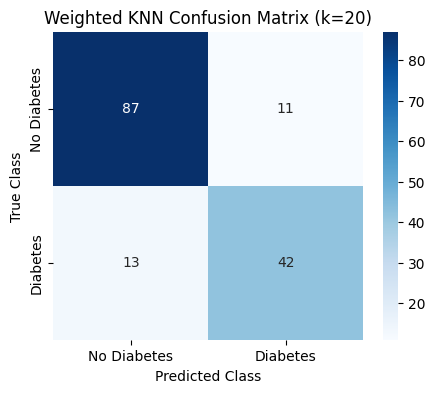

In [116]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_w, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title(f'Weighted KNN Confusion Matrix (k={best_k_w})')
plt.show()

Weighted KNN (k=20) outperforms plain KNN (k=14) across all metrics.
The model correctly classified 87 non-diabetic and 42 diabetic patients.
Compared to plain KNN, the number of false negatives decreased from 16
to 13, meaning fewer diabetic patients were missed. The recall improved
from 70.9% to 76.4%, which is particularly important in a medical context.
The higher optimal k (20 vs 14) confirms that Weighted KNN tolerates
larger neighborhoods better than plain KNN, since distant neighbors
are down-weighted and have less influence on the final prediction.

# 7. Feature-Weighted KNN

In standard KNN all features contribute equally to the distance calculation. In Feature-Weighted KNN each feature is multiplied by a weight that reflects its importance before computing the distance.

We use the **correlation with Outcome** (from Section 1.9) as the feature weights — features that are more strongly correlated with the target variable get a higher weight, so they have more influence on which neighbors are considered close.

This is a natural extension: we already know from EDA that Glucose (0.50) and Insulin (0.38) are the strongest predictors, so it makes sense to give them more weight.

### 7.1 Feature Weights

Each feature is assigned a weight based on how strongly it is
correlated with Outcome — features that are better predictors
of diabetes count more when computing distances between patients.
The weights are normalized so they sum to 1.

In [117]:
# Correlations with Outcome from EDA (Section 1.9)
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

correlations = np.array([0.22, 0.50, 0.17, 0.30, 0.38, 0.32, 0.17, 0.24])

# Normalize so weights sum to 1
feature_weights = correlations / correlations.sum()

for name, w in zip(feature_names, feature_weights):
    print(f'{name:25s}: {w:.4f}')

Pregnancies              : 0.0957
Glucose                  : 0.2174
BloodPressure            : 0.0739
SkinThickness            : 0.1304
Insulin                  : 0.1652
BMI                      : 0.1391
DiabetesPedigreeFunction : 0.0739
Age                      : 0.1043


### 7.2 Implementation

The only change from plain KNN is that before computing the Euclidean distance, each feature is multiplied by its weight. Features with higher correlation with Outcome will contribute more to the distance.

In [118]:
def feature_weighted_knn_predict_point(X_train, y_train, x_query, k=5, weights=None):
    if weights is None:
        weights = np.ones(X_train.shape[1])

    # Apply feature weights before computing distance
    distances = np.array([
        np.sqrt(np.sum(weights * (x - x_query) ** 2))
        for x in X_train
    ])

    # Find k nearest neighbors and take majority vote
    nn_idx = np.argsort(distances)[:k]
    nn_labels = y_train[nn_idx]
    counts = np.bincount(nn_labels)
    return np.argmax(counts)


def feature_weighted_knn_predict(X_train, y_train, X_test, k=5, weights=None):
    return np.array([feature_weighted_knn_predict_point(X_train, y_train, x, k=k, weights=weights)for x in X_test])

### 7.3 Hyperparameter Analysis — Choosing k

Best k (Feature-Weighted KNN): 3
Best accuracy: 0.8431


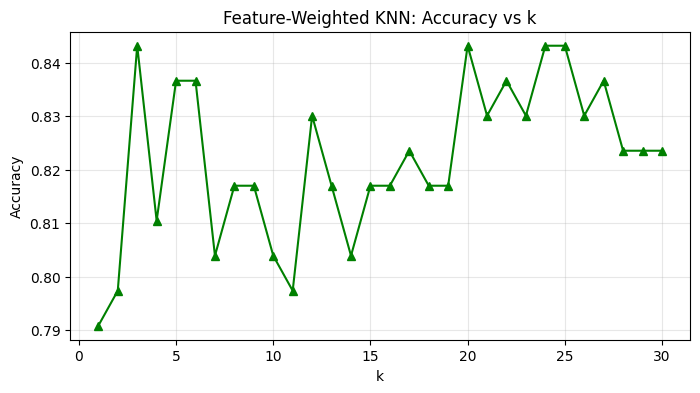

In [119]:
k_values = list(range(1, 31))
accuracies_fwknn = []

for k in k_values:
    y_pred = feature_weighted_knn_predict(
        X_train_scaled, y_train, X_test_scaled, k=k, weights=feature_weights
    )
    accuracies_fwknn.append(np.mean(y_pred == y_test))

best_k_fw = k_values[np.argmax(accuracies_fwknn)]
print(f'Best k (Feature-Weighted KNN): {best_k_fw}')
print(f'Best accuracy: {max(accuracies_fwknn):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies_fwknn, marker='^', color='green')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Feature-Weighted KNN: Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.show()

The best k for Feature-Weighted KNN is 3, which is notably smaller
than plain KNN (k=14) and Distance-Weighted KNN (k=20). This suggests
that by giving more weight to informative features (Glucose, Insulin, BMI),
the model can rely on fewer but more relevant neighbors to make accurate
predictions. With feature weighting, even the 3 closest neighbors in the
weighted feature space provide sufficient information for classification.

### 7.4 Model Evaluation

In [120]:
y_pred_fwknn = feature_weighted_knn_predict(
    X_train_scaled, y_train, X_test_scaled, k=best_k_fw, weights=feature_weights
)

accuracy_fw = np.mean(y_pred_fwknn == y_test)

cm_fw = np.zeros((2, 2), dtype=int)
for true, pred in zip(y_test, y_pred_fwknn):
    cm_fw[int(true), int(pred)] += 1

tn_fw, fp_fw, fn_fw, tp_fw = cm_fw[0,0], cm_fw[0,1], cm_fw[1,0], cm_fw[1,1]

precision_fw = tp_fw / (tp_fw + fp_fw) if (tp_fw + fp_fw) > 0 else 0
recall_fw    = tp_fw / (tp_fw + fn_fw) if (tp_fw + fn_fw) > 0 else 0
f1_fw        = 2 * precision_fw * recall_fw / (precision_fw + recall_fw) if (precision_fw + recall_fw) > 0 else 0

print(f'Accuracy : {accuracy_fw:.4f}')
print(f'Precision: {precision_fw:.4f}')
print(f'Recall   : {recall_fw:.4f}')
print(f'F1-score : {f1_fw:.4f}')

Accuracy : 0.8431
Precision: 0.7627
Recall   : 0.8182
F1-score : 0.7895


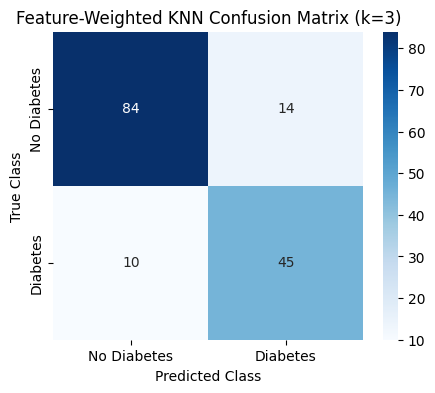

In [121]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_fw, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title(f'Feature-Weighted KNN Confusion Matrix (k={best_k_fw})')
plt.show()

Feature-Weighted KNN (k=3) correctly classified 84 non-diabetic and
45 diabetic patients. With only 10 false negatives, this is the best
recall (81.8%) among all three KNN variants, meaning the model
successfully identifies 8 out of 10 diabetic patients. By giving
more weight to informative features (Glucose, Insulin, BMI), the model
finds more relevant neighbors even with a small k, which explains why
k=3 is sufficient for good performance.